In [410]:
import cvxpy as cp
import networkx as nx
import numpy as np

In [411]:
graph = nx.read_gml("matmult2.gml")
resource_graph = nx.read_gml("aladdin_const_with_mem.gml")
lengths = dict(nx.all_pairs_shortest_path_length(graph))
topo_sort_graph = list(nx.topological_sort(graph))
indices = list(range(1, len(topo_sort_graph) + 1))
position_dict = dict(zip(topo_sort_graph, indices))
graph_nodes = graph.nodes(data=True)

hw_element_counts = {'Eq': 1, 'Regs': 4, 'Buf': 2, 'MainMem': 1, 'Add': 2, 'Mult': 2, 'stall': float('inf')}
# nx.draw_networkx(graph, pos=nx.multipartite_layout(graph, subset_key="layer"), font_size=8)
# print(graph_nodes)

In [412]:
def calculate_longest_path(graph):
    # Dictionary to store the longest path ending at each node
    longest_paths = {node: 0 for node in graph.nodes()}

    # Topological sort of nodes to process them in order
    for node in nx.topological_sort(graph):
        # Start with the node's own duration if defined
        node_end_time = graph.nodes[node]['end_time']
        # Update based on predecessors' longest path
        for pred in graph.predecessors(node):
            pred_end_time = longest_paths[pred]
            # Ensure that the current node's start time is after the predecessor's end time
            if graph.nodes[node]['start_time'] >= pred_end_time:
                longest_paths[node] = max(longest_paths[node], node_end_time)

    # The longest path in the graph is the maximum value in longest_paths
    return max(longest_paths.values())

### Creating variables and Data dependencies

In [413]:
# creating variables
# only need two per node: start and end?
constraints = []
vars = []

# graph nodes
id = 0
for node in graph_nodes:
    curr_var = cp.Variable(2, name = node[0]) # first one is start time and last one is end time
    # curr_var.name = node[0]
    vars.append(curr_var)
    # start time + latency = end time for each operating node
    node[1]['scheduling_id'] = id
    id += 1
    constraints.append(curr_var[0] >= 0)
    # constraints.append(curr_var[1] >= 0)
    if 'cost' in node[1].keys():
        constraints.append(curr_var[0] + node[1]['cost'] == curr_var[1])

# print(graph_nodes)
# nx.set_node_attributes(graph, graph_nodes)
# data dependency constraints
for u, v in graph.edges():
    # if 'idx'
    source_id = int(graph_nodes[u]['scheduling_id'])
    dest_id = int(graph_nodes[v]['scheduling_id'])
    constraints.append(vars[source_id][1] - vars[dest_id][0] <= 0)

### Longest-path priority based topo sort

In [414]:
import heapq

def longest_path_first_topological_sort(graph):
    longest_path_length = {node: 0 for node in graph.nodes()}
    for node in reversed(list(nx.topological_sort(graph))):
        for successor in graph.successors(node):
            longest_path_length[node] = max(longest_path_length[node], 1 + longest_path_length[successor])

    priority_queue = []
    in_degree = {node: 0 for node in graph.nodes()}
    for u, v in graph.edges():
        in_degree[v] += 1
    
    for node in graph.nodes():
        if in_degree[node] == 0:
            heapq.heappush(priority_queue, (-longest_path_length[node], node))

    topological_order = []
    while priority_queue:
        _, node = heapq.heappop(priority_queue)
        topological_order.append(node)
        for successor in graph.successors(node):
            in_degree[successor] -= 1
            if in_degree[successor] == 0:
                heapq.heappush(priority_queue, (-longest_path_length[successor], successor))

    return topological_order

# topo_order_longest_path = longest_path_first_topological_sort(graph)

### NetworkX Topological Sort Dependencies 

In [415]:
# topological_order = list(nx.topological_sort(graph))
# constraints.append(vars[graph_nodes['end']['scheduling_id']][0] <= 20)
topological_order = longest_path_first_topological_sort(graph)
for i in range(len(topological_order)):
    curr_reg_count = {'Regs': 0, 'Add': 0, 'Mult': 0, 'Buf': 0, 'Eq': 0, 'stall': 0}
    start_node = topological_order[i]
    if graph.nodes[start_node]['function'] not in curr_reg_count:
        continue
    curr_reg_count[graph.nodes[start_node]['function']] += 1
    
    for j in range(i + 1, len(topological_order)):
        curr_node = topological_order[j]
        if graph.nodes[curr_node]['function'] not in curr_reg_count.keys():
                continue
        curr_reg_count[graph.nodes[curr_node]['function']] += 1
        if graph.nodes[curr_node]['function'] == graph.nodes[start_node]['function']:
            if curr_reg_count[graph.nodes[curr_node]['function']] > 2*hw_element_counts[graph.nodes[curr_node]['function']]:
                break
            if curr_reg_count[graph.nodes[curr_node]['function']] > hw_element_counts[graph.nodes[curr_node]['function']]:
                # add a constraint
                constraints.append(vars[graph.nodes[start_node]['scheduling_id']][0] - vars[graph.nodes[curr_node]['scheduling_id']][0] <= -graph.nodes[start_node]['cost'])
                break
    # print(curr_reg_count)

In [416]:
# for constraint in constraints:
#     print(str(constraint))

In [417]:
# all_nodes = 0
# for var in vars:
#     all_nodes += var[0]
obj = cp.Minimize(vars[graph_nodes['end']['scheduling_id']][0])
# obj = cp.Minimize(all_nodes)
prob = cp.Problem(obj, constraints)
prob.solve(solver = 'SCS', verbose=True)

                                     CVXPY                                     
                                     v1.4.2                                    
(CVXPY) May 15 02:24:45 PM: Your problem has 114 variables, 217 constraints, and 0 parameters.
(CVXPY) May 15 02:24:45 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) May 15 02:24:45 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) May 15 02:24:45 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) May 15 02:24:45 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) May 15 02:24:45 PM: Compiling problem (target solver=SCS).
(C

20.820047931882886

The longest path duration in the graph is 21.0


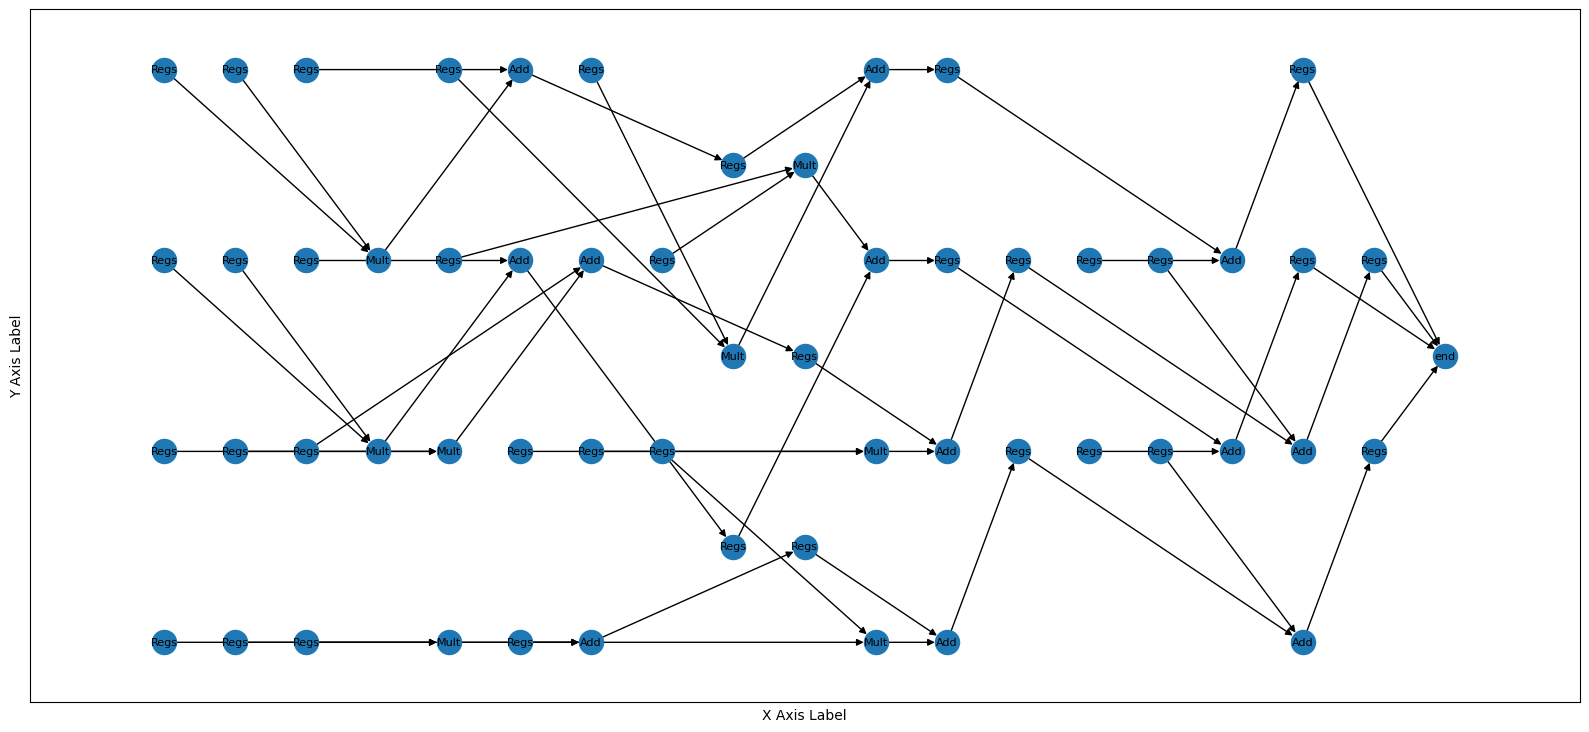

In [409]:
import matplotlib.pyplot as plt
for node in graph_nodes:
    start_time, end_time = vars[node[1]['scheduling_id']].value
    node[1]['start_time'] = np.round(start_time)
    node[1]['end_time'] = np.round(end_time)
plt.figure(figsize=(20,9))
labels = {node: data['function'] for node, data in graph.nodes(data=True)}
nx.draw_networkx(graph, with_labels=True, labels=labels, pos=nx.multipartite_layout(graph, subset_key="start_time"), font_size=8)
ax = plt.gca()

# Set labels for axes
ax.set_xlabel('X Axis Label')
ax.set_ylabel('Y Axis Label')

longest_duration = calculate_longest_path(graph)
print(f"The longest path duration in the graph is {longest_duration}")

In [394]:
for node in graph_nodes: print(node)

('b_1[0][0];37', {'function': 'Regs', 'idx': '37', 'cost': 2, 'scheduling_id': 0, 'start_time': 2.0, 'end_time': 4.0})
('c_1[0][0];39', {'function': 'Regs', 'idx': '39', 'cost': 2, 'scheduling_id': 1, 'start_time': 4.0, 'end_time': 6.0})
('a_1[0][0];36', {'function': 'Regs', 'idx': '36', 'cost': 2, 'scheduling_id': 2, 'start_time': -0.0, 'end_time': 2.0})
('*;38', {'function': 'Mult', 'idx': '38', 'cost': 0.98, 'scheduling_id': 3, 'start_time': 5.0, 'end_time': 6.0})
('+;40', {'function': 'Add', 'idx': '40', 'cost': 0.94, 'scheduling_id': 4, 'start_time': 7.0, 'end_time': 8.0})
('c_1[0][0];41', {'function': 'Regs', 'idx': '39', 'cost': 2, 'scheduling_id': 5, 'start_time': 10.0, 'end_time': 12.0})
('b_1[1][0];37', {'function': 'Regs', 'idx': '37', 'cost': 2, 'scheduling_id': 6, 'start_time': 8.0, 'end_time': 10.0})
('a_1[0][1];36', {'function': 'Regs', 'idx': '36', 'cost': 2, 'scheduling_id': 7, 'start_time': 6.0, 'end_time': 8.0})
('c_1[0][0];42', {'function': 'Regs', 'idx': '44', 'cos

### Generational Resource Dependency (WRONG)

In [244]:
# generations = list(nx.topological_generations(nx.reverse(graph)))
# for elem in generations:
#     nodes = list(filter(lambda x: x[0] in elem, graph.nodes.data()))
#     funcs, counts = np.unique(
#         list(map(lambda x: x[1]["function"], nodes)), return_counts=True
#     )
#     for func, count in zip(funcs, counts):
#         if func == "start" or func == "end":
#                 continue            
#         if count > hw_element_counts[func]:
#             func_nodes = list(filter(lambda x: x[1]["function"] == func, nodes))
#             need_to_be_pushed = count - hw_element_counts[func]
#             sorted_by_outgoing_edges = sorted(func_nodes, key=lambda node: len(graph.out_edges()))
#             for i in range(need_to_be_pushed):
#                 for j in range(i + 1, need_to_be_pushed + 1):
#                     constraints.append(vars[int(func_nodes[i][1]['scheduling_id'])][0] - vars[int(func_nodes[j][1]['scheduling_id'])][0] <= -func_nodes[i][1]['cost'])
#                     # if there are 3 registers and 4 nodes using a register. then how do we encode the constraint?
#                     # every "layer "

### All Topological Sorts Dependencies

In [245]:
def limited_topological_sorts(graph, max_sorts=10):
    in_degree = {node: 0 for node in graph.nodes()}
    for u, v in graph.edges():
        in_degree[v] += 1

    partial_order = []
    sorts_found = 0
    
    def visit():
        nonlocal sorts_found
        if sorts_found >= max_sorts:
            return

        all_visited = True
        for node in graph.nodes():
            if in_degree[node] == 0 and node not in partial_order:
                all_visited = False
                partial_order.append(node)
                for successor in graph.successors(node):
                    in_degree[successor] -= 1

                yield from visit()

                partial_order.pop()
                for successor in graph.successors(node):
                    in_degree[successor] += 1
        
        if all_visited:
            sorts_found += 1
            yield list(partial_order)

    return list(visit())

In [382]:
all_sorted = limited_topological_sorts(graph, max_sorts = 20)

final_vars = []
final_optim_val = float('inf')

all_optim_vals = []
print("Trying", len(all_sorted), "topological sorts")
for top_order in all_sorted:
    curr_constraints = []

    ### Introducing Variables
    vars = []
    id = 0
    for node in graph_nodes:
        curr_var = cp.Variable(2) # first one is start time and last one is end time
        vars.append(curr_var)
        # start time + latency = end time for each operating node
        node[1]['scheduling_id'] = id
        id += 1
        curr_constraints.append(curr_var[0] >= 0)
        curr_constraints.append(curr_var[1] >= 0)
        if 'cost' in node[1].keys():
            curr_constraints.append(curr_var[0] + node[1]['cost'] == curr_var[1])
    
    ### Data Dependencies
    for u, v in graph.edges():
        source_id = int(graph_nodes[u]['scheduling_id'])
        dest_id = int(graph_nodes[v]['scheduling_id'])
        curr_constraints.append(vars[source_id][1] - vars[dest_id][0] <= 0)
        
    ### Resource Dependencies
    for i in range(len(top_order)):
        curr_reg_count = {'Regs': 0, 'Add': 0, 'Mult': 0, 'Buf': 0, 'Eq': 0, 'stall': 0}
        start_node = top_order[i]
        if graph.nodes[start_node]['function'] not in curr_reg_count:
            continue
        curr_reg_count[graph.nodes[start_node]['function']] += 1
        for j in range(i + 1, len(top_order)):
            curr_node = top_order[j]
            if graph.nodes[curr_node]['function'] not in curr_reg_count:
                continue
            curr_reg_count[graph.nodes[curr_node]['function']] += 1
            if graph.nodes[curr_node]['function'] == graph.nodes[start_node]['function']:
                if curr_reg_count[graph.nodes[curr_node]['function']] > 2 * hw_element_counts[graph.nodes[curr_node]['function']]:
                    break
                if curr_reg_count[graph.nodes[curr_node]['function']] > hw_element_counts[graph.nodes[curr_node]['function']]:
                    # add a constraint
                    curr_constraints.append(vars[graph.nodes[start_node]['scheduling_id']][0] - vars[graph.nodes[curr_node]['scheduling_id']][0] <= -graph.nodes[start_node]['cost'])
    
    # constraints += curr_constraints
    obj = cp.Minimize(vars[graph_nodes['end']['scheduling_id']][0])
    prob = cp.Problem(obj, curr_constraints)
    prob.solve()
    all_optim_vals.append(prob.value)
    if prob.value < final_optim_val:
        final_optim_val = prob.value
        final_vars = vars
print("End Node Optimal Time: ", final_optim_val)
print("All Optimal Values: ", all_optim_vals)
# print("All generated same optimal time:", all(i == all_optim_vals[0] for i in all_optim_vals))

Trying 20 topological sorts
End Node Optimal Time:  38.38000000432903
All Optimal Values:  [38.3800000050084, 38.38000040926707, 38.38000040926707, 38.38000040926707, 38.38000043606527, 38.38000000500839, 38.38000040926707, 38.38000040926707, 38.38000040926707, 38.38000043606526, 38.380000005354326, 38.380000005354326, 38.3800003811148, 38.380000368438544, 38.380000368438544, 38.380000368438544, 38.380000375563654, 38.38000000432903, 38.38000036037993, 38.38000036037993]


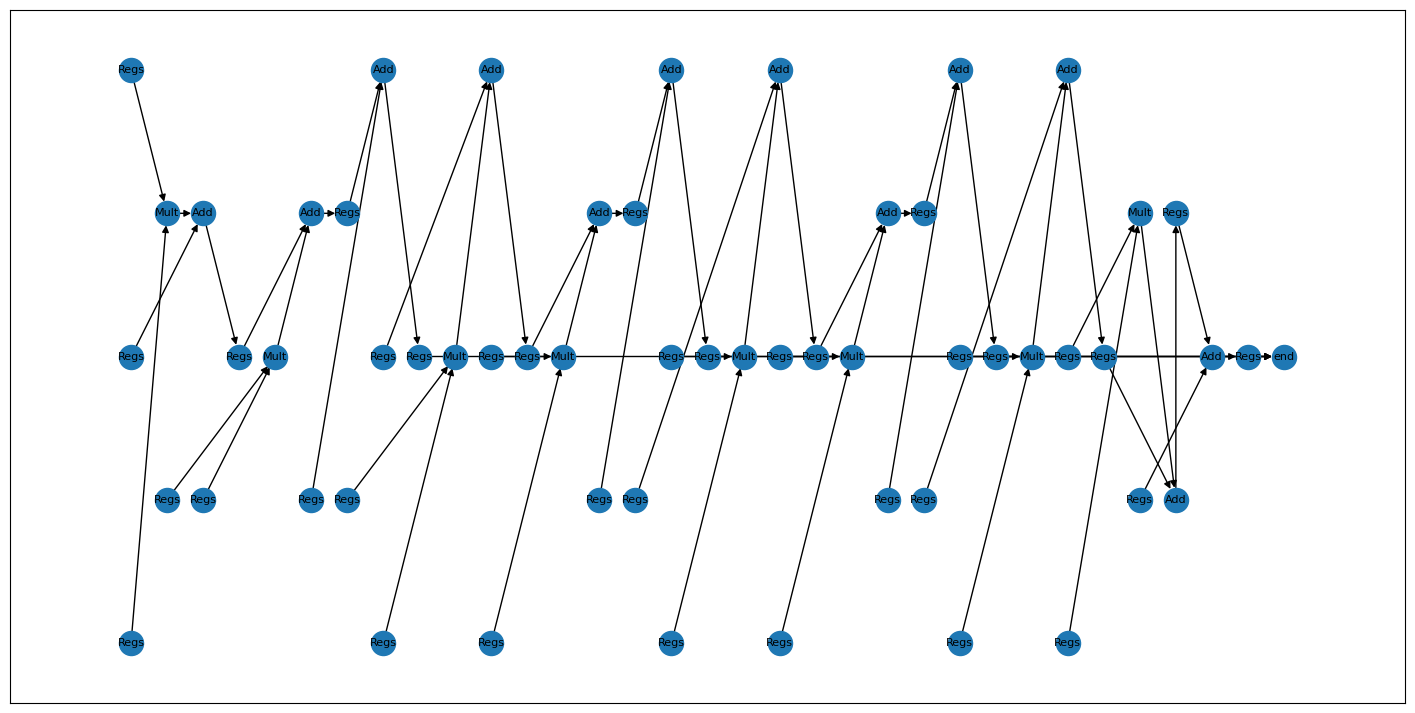

In [383]:
import matplotlib.pyplot as plt
for node in graph_nodes:
    start_time, end_time = vars[node[1]['scheduling_id']].value
    node[1]['start_time'] = np.round(start_time)
    node[1]['end_time'] = np.round(end_time)
plt.figure(figsize=(18,9))
labels = {node: data['function'] for node, data in graph.nodes(data=True)}
nx.draw_networkx(graph, with_labels=True, labels=labels, pos=nx.multipartite_layout(graph, subset_key="start_time"), font_size = 8, label='function')
# nx.draw_networkx(graph, pos=nx.spring_layout(graph), font_size = 8, label='start_time')

In [381]:
# nx.draw_networkx(graph, pos=nx.multipartite_layout(graph, subset_key="layer"), font_size = 8, label='function')
cycles = nx.dag_longest_path_length(graph)
print("Longest path before Vamshi optimization:", cycles)

Longest path before Vamshi optimization: 11.799999999999999


In [189]:
def assign_upstream_path_lengths(graph):
    """
    Assigns the longest path to each node in the graph.
    Currently ignores actual latencies of nodes.
    TODO: change this to dijkstra
    """
    for node in graph:
        graph.nodes[node]["dist"] =  0
    for i, generations in enumerate(nx.topological_generations(graph)):
        for node in generations:
            graph.nodes[node]["dist"] = max(i, graph.nodes[node]["dist"])
    
    return graph


In [224]:
def greedy_schedule(computation_graph, hw_element_counts):
    """
    Schedules the computation graph on the hardware netlist
    by determining the order of operations and the states in which
    they are executed. Includes the adding of stalls to account for
    data dependencies and in use elements.
    """

    hw_element_counts["stall"] = np.inf
    # print(f"hw_element_counts: {hw_element_counts}")

    # do topo sort from beginning and add dist attribute to each node
    # for longest path to get to it from a gen[0] node.

    # reset layers:
    for node in computation_graph.nodes:
        computation_graph.nodes[node]["layer"] = -np.inf
    assign_upstream_path_lengths(computation_graph)

    stall_counter = 0 # used to ensure unique stall names
    pushed = []
    # going through the computation graph from the end to the beginning and bubbling up operations
    generations = list(nx.topological_generations(nx.reverse(computation_graph)))
    layer = 0
    while layer < len(generations) or len(pushed) != 0:
        # print(f"layer: {layer}; pushed: {pushed}")
        if layer >= len(generations):
            generation = []
        else:
            generation = generations[layer]
        generation += pushed
        pushed = []

        # if any horizontal dependencies, push them to the next layer
        for node in generation:
            out_nodes = list(map(lambda x: x[1], computation_graph.out_edges(node)))
            intersect = set(out_nodes).intersection(set(generation))
            if intersect:
                pushed.append(node)
            else:
                computation_graph.nodes[node]["allocation"] = ""
                computation_graph.nodes[node]["layer"] = -layer
        # print(f"generation before removing horizontal: {generation}")
        generation = [
            item for item in generation if item not in pushed
        ]
        # print(f"generation after removing horizontal: {generation}")

        nodes_in_gen = list(filter(lambda x: x[0] in generation, computation_graph.nodes.data()))
        # print(f"layers in gen: {list(map(lambda x: x[1]['layer'], nodes_in_gen))}")
        funcs_in_gen, counts_in_gen = np.unique(
            list(map(lambda x: x[1]["function"], nodes_in_gen)), return_counts=True
        )

        for func, count in zip(funcs_in_gen, counts_in_gen): # for each function in the generation
            # print(f"func: {func}; count: {count}")
            if func == "start" or func == "end":
                continue
            if count > hw_element_counts[func]:
                # print(f"more ops than hw elements for {func}")
                func_nodes = list(filter(lambda x: x[1]["function"] == func, nodes_in_gen))
                # print(f"func_nodes: {func_nodes}")
                func_nodes = sorted(func_nodes, key=lambda x: x[1]["dist"], reverse=True)
                # print(f"sorted func_nodes: {func_nodes}")

                start_idx = hw_element_counts[func]
                # TODO: pic this range based on upstream length. Calculated by Dijkstra
                for idx in range(start_idx, count):
                    # print(f"idx: {idx}; node: {func_nodes[idx][0]}; removing node from gen")
                    # generation.remove(func_nodes[idx][0])
                    # an out edge in comp_dfg is an in_edge in the reversed_graph
                    out_edges = list(computation_graph.out_edges(func_nodes[idx][0]))

                    stall_name = f"stall_{layer}_{idx}_{func}_{stall_counter}"
                    stall_counter += 1
                    # print(f"adding stall: {stall_name} for {func}")
                    computation_graph.add_node(
                        stall_name,
                        function="stall",
                        cost=func_nodes[idx][1]["cost"],
                        layer= -layer,
                    )
                    # print(f"adding stall: {stall_name}: {computation_graph.nodes[stall_name]}")
                    new_edges = []
                    for edge in out_edges:
                        new_edges.append((stall_name, edge[1], {"weight": computation_graph.edges[edge]["weight"]}))
                        new_edges.append((edge[0], stall_name, {"weight": computation_graph.edges[edge]["weight"]})) # edge[0] is same as func_nodes[idx][0]
                    computation_graph.add_edges_from(
                        new_edges
                    )
                    computation_graph.remove_edges_from(out_edges)

                    computation_graph.nodes[func_nodes[idx][0]]["layer"] = -(layer + 1) # bubble up
                    # print(f"node after bubbling: {func_nodes[idx][0]}: {computation_graph.nodes[func_nodes[idx][0]]}")
                    pushed.append(func_nodes[idx][0])

        # print(f"plotting processed graph")
        hopeful_nodes = list(filter(
            lambda x: x[1]["layer"] >= -layer, computation_graph.nodes.data()
        ))
        # print(f"layers: {[x[1]['layer'] for x in hopeful_nodes]}")
        processed_nodes = list(map(lambda x: x[0], hopeful_nodes))
        # print(f"processed_nodes: {processed_nodes}")
        processed_graph = nx.subgraph(computation_graph, processed_nodes)

        curr_gen_nodes = list(filter(lambda x: x[1]["layer"] == -layer, computation_graph.nodes.data()))
        funcs_in_gen, counts_in_gen = np.unique(
            list(map(lambda x: x[1]["function"], curr_gen_nodes)), return_counts=True
        )

        for i, func in enumerate(funcs_in_gen):
            if func in ["start", "end"]:
                continue
            assert counts_in_gen[i] <= hw_element_counts[func]

        # print(f"funcs_in_gen: {funcs_in_gen}; counts_in_gen: {counts_in_gen}")
        # print(f"hw_element_counts: {hw_element_counts}")

        layer += 1
    cycles = nx.dag_longest_path_length(computation_graph)
    plt.figure(figsize=(15,9))
    labels = {node: data['function'] for node, data in graph.nodes(data=True)}
    nx.draw_networkx(graph, with_labels = True, labels=labels, pos=nx.multipartite_layout(graph, subset_key="layer"), font_size = 8, label='function')
    # for node in computation_graph.nodes(data=True):
    #     print
    print("Vamshi Scheduling Cycles: ",  cycles)

Vamshi Scheduling Cycles:  18.379999999999995


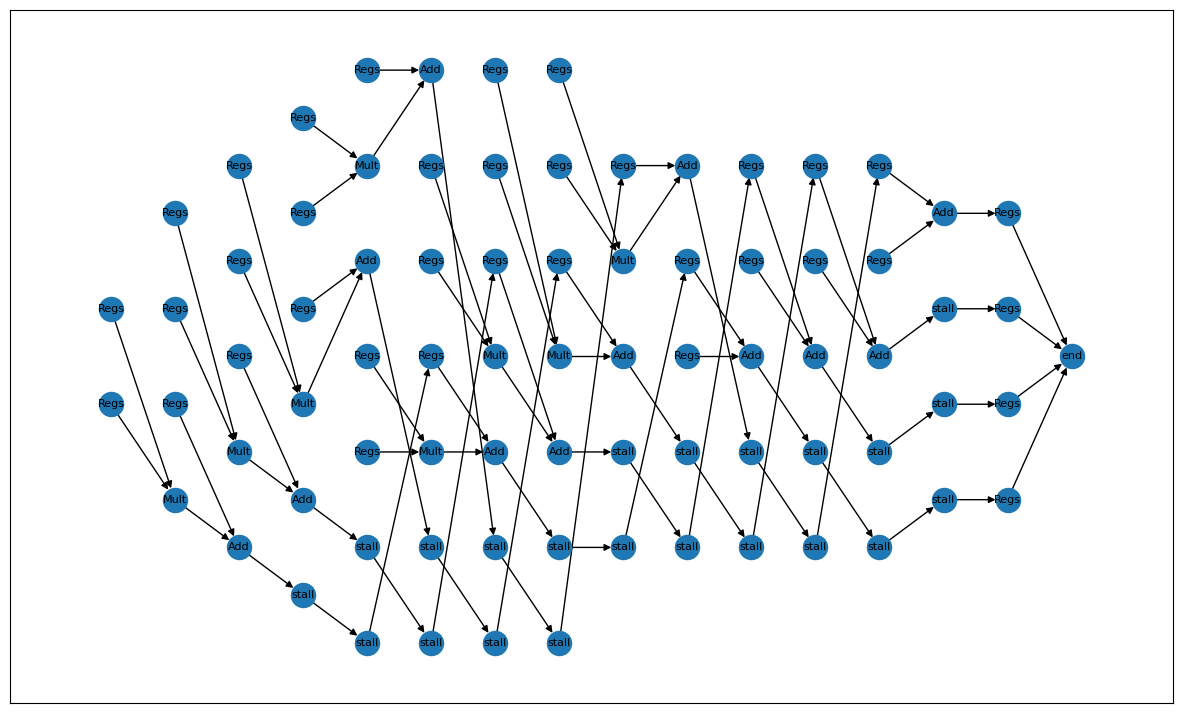

In [225]:
# get them back in order
greedy_schedule(graph, hw_element_counts)

### Results

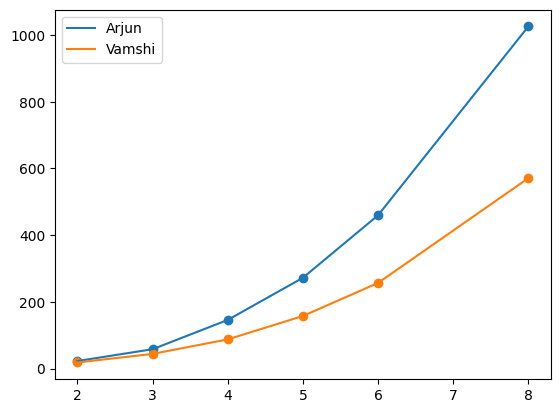

In [380]:
n = [2, 3, 4, 5, 6, 8]
arjun = [22.7, 58.09, 145.88, 272.14, 459.5, 1025.6]
vamsh = [18.380, 44.12, 87.6, 157.64, 256.7, 570.80]
plt.plot(n, arjun, label = "Arjun")
plt.scatter(n, arjun)
plt.plot(n, vamsh, label = "Vamshi")
plt.scatter(n, vamsh)
plt.legend()

In [308]:
graph_nodes

NodeDataView({'b_1[0][0];37': {'function': 'Regs', 'idx': '37', 'cost': 2, 'scheduling_id': 0, 'start_time': -0.0, 'end_time': 2.0}, 'c_1[0][0];39': {'function': 'Regs', 'idx': '39', 'cost': 2, 'scheduling_id': 1, 'start_time': -0.0, 'end_time': 2.0}, 'a_1[0][0];36': {'function': 'Regs', 'idx': '36', 'cost': 2, 'scheduling_id': 2, 'start_time': -0.0, 'end_time': 2.0}, '*;38': {'function': 'Mult', 'idx': '38', 'cost': 0.98, 'scheduling_id': 3, 'start_time': 2.0, 'end_time': 2.98}, '+;40': {'function': 'Add', 'idx': '40', 'cost': 0.94, 'scheduling_id': 4, 'start_time': 2.98, 'end_time': 3.92}, 'c_1[0][0];41': {'function': 'Regs', 'idx': '39', 'cost': 2, 'scheduling_id': 5, 'start_time': 3.92, 'end_time': 5.92}, 'b_1[1][0];37': {'function': 'Regs', 'idx': '37', 'cost': 2, 'scheduling_id': 6, 'start_time': -0.0, 'end_time': 2.0}, 'a_1[0][1];36': {'function': 'Regs', 'idx': '36', 'cost': 2, 'scheduling_id': 7, 'start_time': -0.0, 'end_time': 2.0}, 'c_1[0][0];42': {'function': 'Regs', 'idx':